# Лабораторная 3: Сегментация дорожных знаков



## Задания



* Предобученные модели детекции такие как Mask R CNN детектируют и сегментируют объект

  фиксированных классов, в том числе знаки «Стоп»

* Предлагается обучить выбранную модель сегментировать 8 типов знаков на наборе данных

  Russian road signs <https://www.kaggle.com/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset>

  содержащем 100000 изображений дорожных знаков России

* Предобученные модели можно использовать из библиотеки MMSegmentation, а можно попробовать YOLOv11 и другие

* Тестирование провести на видео с улиц с дорожными знаками (3+ видео по 30+ секунд), сделанных

  самостоятельно около Университета ИТМО

* Оценка качества сегментации производится с помощью метрик IoU, Precision, Recall, L2 отдельно

  на валидационной части набора изображений и сделанных видео; также интересует процент изображений,

  на котором IoU >= 0.5, IoU >= 0.75, IoU >= 0.9

* Запустить два любых алгоритма трекинга на отснятых видео и оценить результат — посчитать

  метрику ID Switches

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from __future__ import annotations

import subprocess
import zipfile
from dataclasses import dataclass, field
from pathlib import Path


@dataclass
class Config:
    """Single switch between CPU smoke-test and full GPU training."""

    mode: str = "cpu"  # "cpu" for local debug, "gpu" for Colab T4/v5e-1

    # ---- Paths (all configurable) ----
    datasets_dir: Path = field(default_factory=lambda: Path("datasets"))
    videos_dir: Path = field(default_factory=lambda: Path("drive/MyDrive/cv-cource"))
    project_dir: Path = field(default_factory=lambda: Path("runs/lab3"))

    model_name: str = "yolo11n-seg.pt"
    kaggle_dataset: str = "viacheslavshalamov/russian-road-signs-segmentation-dataset"
    conf_threshold: float = 0.25

    @property
    def device(self) -> str:
        import torch
        if self.mode == "cpu":
            return "cpu"
        return "cuda" if torch.cuda.is_available() else "cpu"

    @property
    def epochs(self) -> int:
        return 1 if self.mode == "cpu" else 50

    @property
    def batch_size(self) -> int:
        return 4 if self.mode == "cpu" else 16

    @property
    def imgsz(self) -> int:
        return 320 if self.mode == "cpu" else 640

    @property
    def data_fraction(self) -> float:
        """Fraction of data used during training (tiny slice for CPU smoke-test)."""
        return 0.005 if self.mode == "cpu" else 1.0

    @property
    def eval_samples(self) -> int:
        """Max images for per-image IoU analysis."""
        return 20 if self.mode == "cpu" else 500


cfg = Config(mode="gpu")


In [4]:
!pip install kaggle ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


In [8]:
import csv
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from ultralytics import YOLO

print(f"Torch: {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device: {cfg.device}")
print(f"Videos dir : {cfg.videos_dir.resolve()}")
print(f"Datasets dir: {cfg.datasets_dir.resolve()}")


Torch: 2.10.0+cu128 | CUDA: True | Device: cuda
Videos dir : /content/drive/MyDrive/cv-cource
Datasets dir: /content/datasets


## 1. Подготовка данных



Датасет: **Russian Road Signs Segmentation**

- ~100 000 изображений, 8 классов

- Kaggle: `viacheslavshalamov/russian-road-signs-segmentation-dataset`

- Формат: YOLO-segmentation (полигональные маски)

In [9]:
import json as _json


def _download_if_needed(kaggle_slug: str, dest: Path) -> None:
    """Download and extract the Kaggle dataset zip into dest if not already present."""
    # Already extracted if any via_region_data.json exists under dest
    if list(dest.rglob("via_region_data.json")):
        return

    dest.mkdir(parents=True, exist_ok=True)
    zips = list(dest.parent.glob("*.zip"))
    if not zips:
        print("Downloading from Kaggle ...")
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", kaggle_slug, "-p", str(dest.parent)],
            check=True,
        )
        zips = list(dest.parent.glob("*.zip"))

    if not zips:
        raise FileNotFoundError(f"No zip found in {dest.parent} after download.")

    print(f"Extracting {zips[0].name} ...")
    with zipfile.ZipFile(zips[0], "r") as zf:
        zf.extractall(dest)


def _find_via_split_dirs(root: Path) -> dict[str, Path]:
    """Return {split_name: dir_path} for each dir that contains via_region_data.json."""
    result: dict[str, Path] = {}
    for via_file in sorted(root.rglob("via_region_data.json")):
        split_name = via_file.parent.name  # "train" or "val"
        result[split_name] = via_file.parent
    return result


def convert_via_to_yolo(root: Path, yolo_root: Path, class_names: list[str]) -> Path:
    """Convert VIA-format road signs dataset → YOLO segmentation layout.

    Input layout (per split dir): N.jpg + via_region_data.json
    Output layout:
      yolo_root/{train,val}/images/*.jpg
      yolo_root/{train,val}/labels/*.txt   (YOLO seg: cls x1 y1 x2 y2 ...)
      yolo_root/data.yaml
    """
    if (yolo_root / "data.yaml").exists():
        print(f"YOLO dataset already at {yolo_root}")
        return yolo_root

    print("Converting VIA → YOLO segmentation format ...")
    name_to_id = {n: i for i, n in enumerate(class_names)}
    split_dirs = _find_via_split_dirs(root)

    for split, src_dir in split_dirs.items():
        out_images = yolo_root / split / "images"
        out_labels = yolo_root / split / "labels"
        out_images.mkdir(parents=True, exist_ok=True)
        out_labels.mkdir(parents=True, exist_ok=True)

        with open(src_dir / "via_region_data.json") as f:
            via_data = _json.load(f)

        converted = 0
        for entry in via_data.values():
            fname = entry["filename"]
            src_img = src_dir / fname
            if not src_img.exists():
                continue

            w_img = float(entry["file_attributes"].get("width", 1) or 1)
            h_img = float(entry["file_attributes"].get("height", 1) or 1)

            lines = []
            for region in entry["regions"].values():
                cls_name = region["region_attributes"].get("name", "").strip()
                if cls_name not in name_to_id:
                    continue
                cls_id = name_to_id[cls_name]
                shape = region["shape_attributes"]
                if shape.get("name") != "polygon" or "all_points_x" not in shape:
                    continue
                xs = shape["all_points_x"]
                ys = shape["all_points_y"]
                if len(xs) < 3:
                    continue
                coords = " ".join(
                    f"{x / w_img:.6f} {y / h_img:.6f}" for x, y in zip(xs, ys)
                )
                lines.append(f"{cls_id} {coords}")

            if not lines:
                continue

            shutil.copy2(src_img, out_images / fname)
            (out_labels / (Path(fname).stem + ".txt")).write_text("\n".join(lines) + "\n")
            converted += 1

        print(f"  {split}: {converted} images converted")

    with open(yolo_root / "data.yaml", "w") as f:
        yaml.dump(
            {
                "path": str(yolo_root.resolve()),
                "train": "train/images",
                "val": "val/images",
                "nc": len(class_names),
                "names": class_names,
            },
            f,
        )

    print(f"YOLO dataset ready at {yolo_root}")
    return yolo_root


# Dataset setup
_raw_root = cfg.datasets_dir / "roadsigns"
_yolo_root = cfg.datasets_dir / "roadsigns_yolo"

_download_if_needed(cfg.kaggle_dataset, _raw_root)
_split_dirs = _find_via_split_dirs(_raw_root)
if not _split_dirs:
    raise FileNotFoundError(
        f"No via_region_data.json found under {_raw_root}. "
        "Please ensure the Kaggle dataset was extracted there."
    )

# The dataset has one class; note the task says 8 types — this Kaggle version uses
# a single "road sign" label covering all sign categories.
CLASS_NAMES: list[str] = ["road sign"]
NUM_CLASSES: int = len(CLASS_NAMES)

roadsigns_path = convert_via_to_yolo(_raw_root, _yolo_root, CLASS_NAMES)
roadsigns_yaml = roadsigns_path / "data.yaml"

print(f"\n{NUM_CLASSES} class(es): {CLASS_NAMES}")
for split in ("train", "val"):
    n = len(list((roadsigns_path / split / "images").glob("*")))
    print(f"  {split:6s}: {n} images")



Converting VIA → YOLO segmentation format ...
  train: 1841 images converted
  val: 109 images converted
YOLO dataset ready at datasets/roadsigns_yolo

1 class(es): ['road sign']
  train : 1841 images
  val   : 109 images


/tmp/ipykernel_4111/2607937583.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


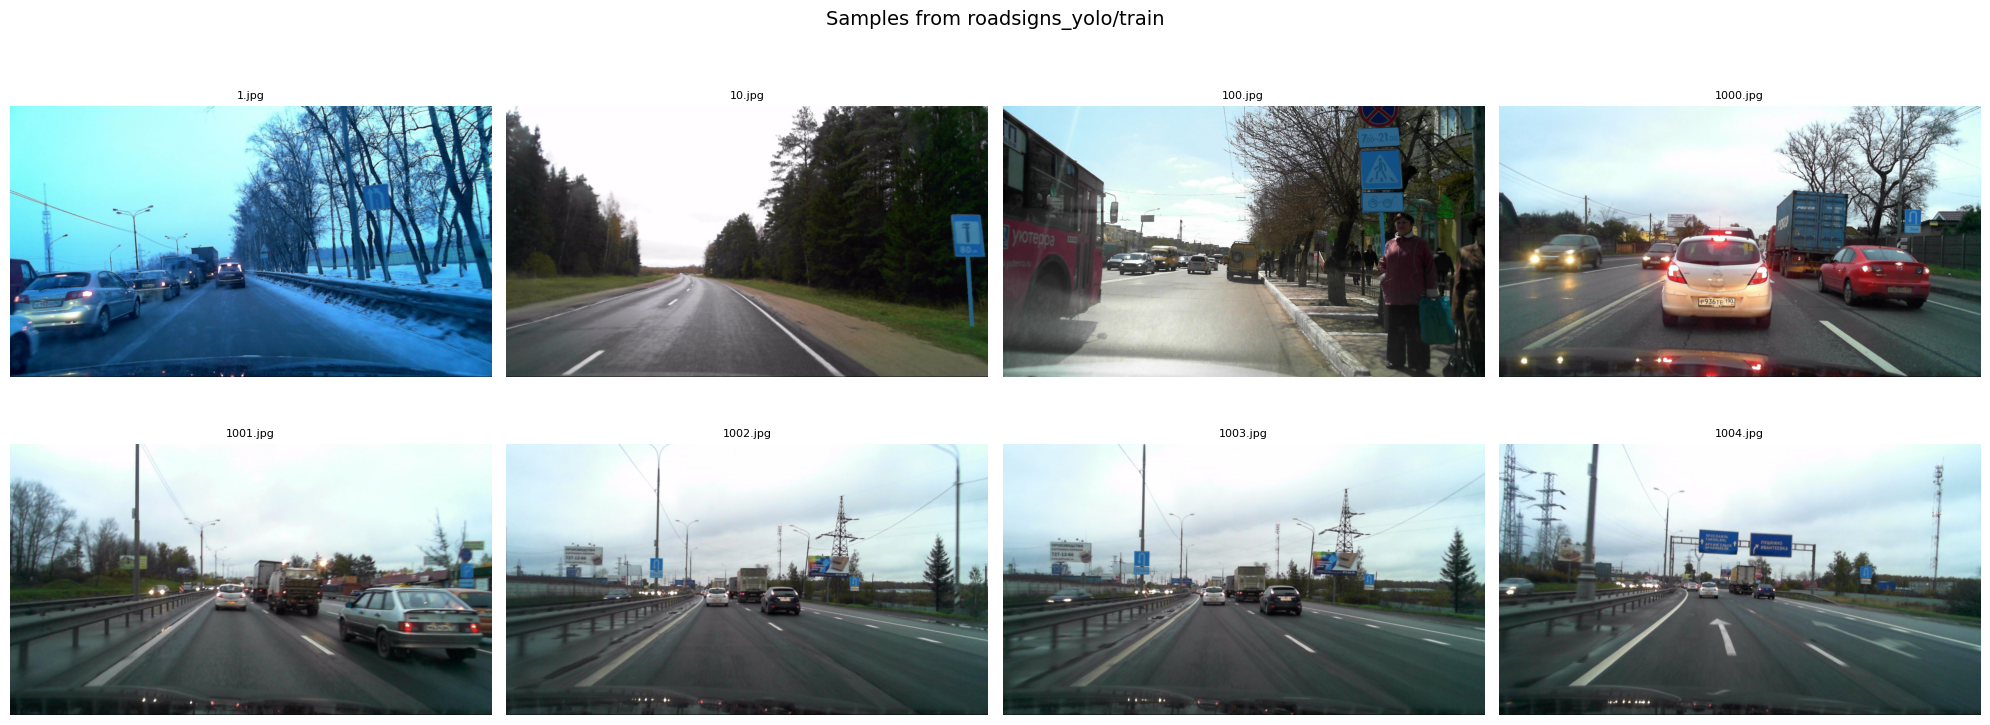

In [10]:
def _polygon_to_mask(points_norm: np.ndarray, h: int, w: int) -> np.ndarray:
    """Convert normalized polygon [[x,y],...] to a binary HxW mask."""
    pts = (points_norm * np.array([w, h])).astype(np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def visualize_samples(dataset_path: Path, split: str = "train", n: int = 8) -> None:
    """Show sample images with ground-truth segmentation masks overlaid."""
    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"
    image_files = sorted(images_dir.glob("*"))[:n]

    cols = min(4, n)
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    ax_flat = axes.flat

    cmap = plt.cm.get_cmap("Reds", NUM_CLASSES)

    for ax, img_path in zip(ax_flat, image_files):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]
        overlay = img.copy()

        label_path = labels_dir / (img_path.stem + ".txt")
        if label_path.exists():
            for line in label_path.read_text().strip().splitlines():
                parts = list(map(float, line.split()))
                cls_id = int(parts[0])
                coords = np.array(parts[1:]).reshape(-1, 2)
                mask = _polygon_to_mask(coords, h_img, w_img)
                color = (np.array(cmap(cls_id)[:3]) * 255).astype(np.uint8)
                overlay[mask == 1] = (overlay[mask == 1] * 0.4 + color * 0.6).astype(np.uint8)

        ax.imshow(overlay)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    for ax in ax_flat[len(image_files):]:
        ax.axis("off")

    plt.suptitle(f"Samples from {dataset_path.name}/{split}", fontsize=14)
    plt.tight_layout()
    plt.show()


visualize_samples(roadsigns_path, "train", n=8)
# Note: val split is named "val" (not "valid") in this dataset


## 2. Обучение модели



Модель: **YOLOv11n-seg** (nano, instance segmentation), дообучение от COCO pretrained весов.



Выбор обоснован:

- Единый стек с Лаб. 2 (ultralytics), простая интеграция трекеров

- Нативная поддержка instance segmentation (полигональные маски)

- Быстрое обучение на T4 — 50 эпох за ~2-3 ч

In [11]:
def train_model(data_yaml: str | Path, base_weights: str, name: str) -> YOLO:
    """Train YOLOv11-seg and return the best checkpoint."""
    model = YOLO(base_weights)
    model.train(
        data=str(data_yaml),
        epochs=cfg.epochs,
        batch=cfg.batch_size,
        imgsz=cfg.imgsz,
        device=cfg.device,
        project=str(cfg.project_dir),
        name=name,
        patience=10,
        fraction=cfg.data_fraction,
        save=True,
        plots=True,
        verbose=True,
        exist_ok=True,
    )
    weights_dir = cfg.project_dir / name / "weights"
    best = weights_dir / "best.pt"
    last = weights_dir / "last.pt"
    chosen = best if best.exists() else last
    if not chosen.exists():
        raise FileNotFoundError(f"No weights found in {weights_dir}")
    return YOLO(str(chosen))



In [12]:
_weights_dir = cfg.project_dir / "train" / "weights"
_existing = next((_weights_dir / w for w in ("best.pt", "last.pt") if (_weights_dir / w).exists()), None)
if _existing is None:
    print("=== Training YOLOv11n-seg on Russian Road Signs ===")
    model = train_model(roadsigns_yaml, cfg.model_name, name="train")
else:
    print(f"Trained weights found: {_existing}")
    model = YOLO(str(_existing))



=== Training YOLOv11n-seg on Russian Road Signs ===
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/roadsigns_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize

FileNotFoundError: No weights found in runs/lab3/train/weights

In [15]:
_existing = next((_weights_dir / w for w in ("best.pt", "last.pt") if (_weights_dir / w).exists()), None)
if _existing is not None:
    print(f"Trained weights found: {_existing}")
    model = YOLO(str(_existing))

Trained weights found: runs/lab3/train/weights/best.pt


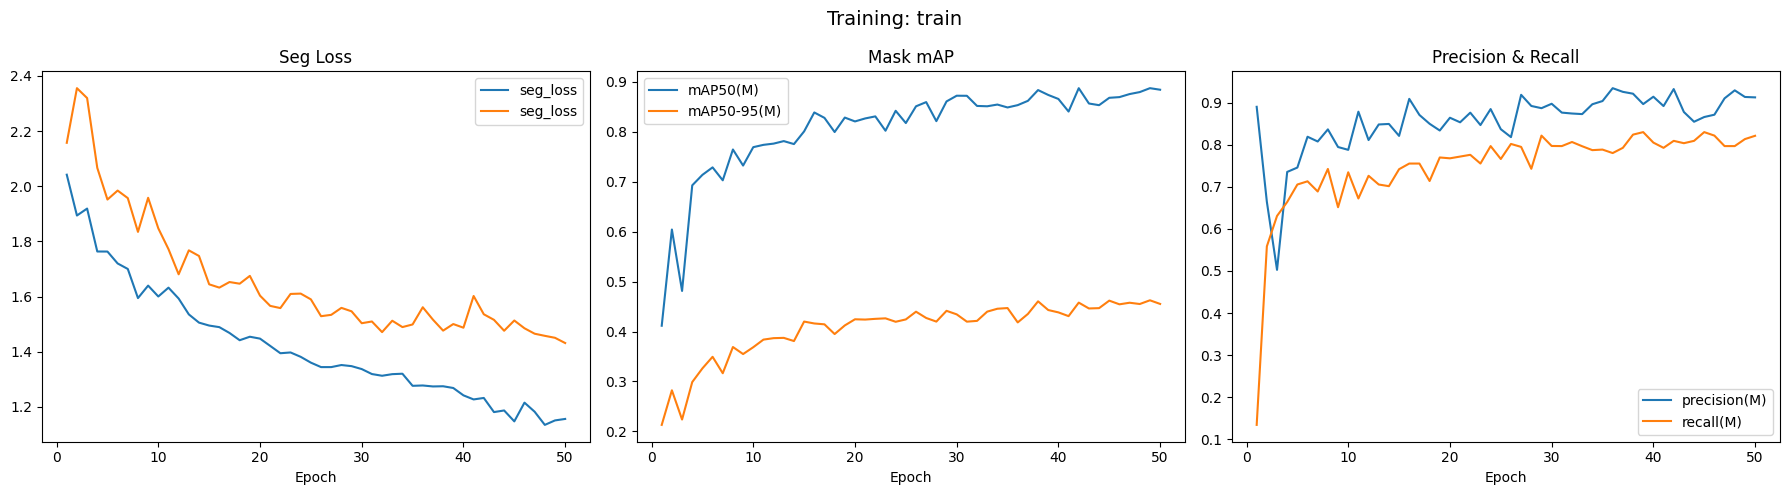

In [14]:
def plot_training_curves(run_dir: Path) -> None:
    """Plot seg/box loss and mAP curves from ultralytics results.csv."""
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        print(f"No results.csv at {results_csv}")
        return

    with open(results_csv) as f:
        rows = [{k.strip(): v.strip() for k, v in row.items()} for row in csv.DictReader(f)]

    epochs = list(range(1, len(rows) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    def _plot(ax, keys, title):
        for key in keys:
            vals = [float(r.get(key, 0) or 0) for r in rows]
            ax.plot(epochs, vals, label=key.split("/")[-1])
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    _plot(axes[0], ["train/seg_loss", "val/seg_loss"], "Seg Loss")
    _plot(axes[1], ["metrics/mAP50(M)", "metrics/mAP50-95(M)"], "Mask mAP")
    _plot(axes[2], ["metrics/precision(M)", "metrics/recall(M)"], "Precision & Recall")

    plt.suptitle(f"Training: {run_dir.name}", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_training_curves(cfg.project_dir / "train")


## 3. Оценка качества на валидационном наборе



Метрики:

- **IoU** (mask), **Precision**, **Recall**, **mAP@0.5** — из ultralytics val()

- **L2** (маска) — пиксельное среднеквадратичное расстояние предсказанной/GT маски

- **% изображений с IoU ≥ 0.5 / 0.75 / 0.9**

- Примеры предсказаний (сетка изображений)

In [16]:
val_results = model.val(
    data=str(roadsigns_yaml),
    split="val",  # "val" split (same key as in data.yaml)
    device=cfg.device,
    plots=True,
    verbose=True,
)

summary = {
    "mAP@0.5 (mask)": float(val_results.seg.map50),
    "mAP@0.5:0.95 (mask)": float(val_results.seg.map),
    "Precision (mask)": float(val_results.seg.mp),
    "Recall (mask)": float(val_results.seg.mr),
}

print("\n" + "=" * 55)
print("VALIDATION SET METRICS")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k:30s}: {v:.4f}")
print("=" * 55)



Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2104.2±544.7 MB/s, size: 96.0 KB)
val: Scanning /content/datasets/roadsigns_yolo/val/labels.cache... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 32.7Mit/s 0.0s
val: /content/datasets/roadsigns_yolo/val/images/207.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/211.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/213.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/214.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/216.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/223.jpg: corrupt JPEG restored and saved
val: /content/datasets/roadsigns_yolo/val/images/225.jpg: co

In [18]:
def _masks_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """IoU between two binary masks."""
    intersection = float((mask_a & mask_b).sum())
    union = float((mask_a | mask_b).sum())
    return intersection / union if union > 0 else 0.0


def _masks_l2(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """Normalised L2 pixel distance between two binary masks."""
    n = mask_a.size
    return float(np.sqrt(np.sum((mask_a.astype(np.float32) - mask_b.astype(np.float32)) ** 2) / n))


def per_image_metrics(
    model: YOLO, dataset_path: Path, split: str = "valid", n_samples: int = 200
) -> pd.DataFrame:
    """Compute per-image mean mask IoU and L2 vs ground truth polygons."""
    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"
    image_files = sorted(images_dir.glob("*"))[:n_samples]

    records = []
    for img_path in image_files:
        label_path = labels_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]

        # Parse GT polygons
        gt_entries: list[tuple[int, np.ndarray]] = []
        for line in label_path.read_text().strip().splitlines():
            parts = list(map(float, line.split()))
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:]).reshape(-1, 2)
            gt_entries.append((cls_id, _polygon_to_mask(coords, h_img, w_img)))

        if not gt_entries:
            continue

        result = model.predict(
            source=str(img_path), conf=cfg.conf_threshold, device=cfg.device, verbose=False
        )[0]

        if result.masks is None or len(result.masks) == 0:
            records.append({"image": img_path.name, "mean_iou": 0.0, "mean_l2": 1.0})
            continue

        # Resize pred masks to original image size
        pred_masks_raw = result.masks.data.cpu().numpy()  # (N, mH, mW)
        pred_cls = result.boxes.cls.cpu().numpy().astype(int) if result.boxes else np.zeros(len(pred_masks_raw), int)

        pred_masks = [
            cv2.resize(m, (w_img, h_img), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
            for m in pred_masks_raw
        ]

        # Match each GT mask to best-IoU prediction of same class
        img_ious, img_l2s = [], []
        for gt_cls, gt_mask in gt_entries:
            best_iou, best_l2 = 0.0, 1.0
            for pm, pc in zip(pred_masks, pred_cls):
                if pc != gt_cls:
                    continue
                iou = _masks_iou(gt_mask, pm)
                if iou > best_iou:
                    best_iou = iou
                    best_l2 = _masks_l2(gt_mask, pm)
            img_ious.append(best_iou)
            img_l2s.append(best_l2)

        records.append({
            "image": img_path.name,
            "mean_iou": float(np.mean(img_ious)),
            "mean_l2": float(np.mean(img_l2s)),
        })

    return pd.DataFrame(records)


df_val = per_image_metrics(model, roadsigns_path, "val", cfg.eval_samples)
print(f"\nPer-image metrics on {len(df_val)} val images:")
print(df_val[["mean_iou", "mean_l2"]].describe().round(4).to_string())




Per-image metrics on 109 val images:
       mean_iou   mean_l2
count  109.0000  109.0000
mean     0.5379    0.1022
std      0.1693    0.1932
min      0.0000    0.0170
25%      0.4581    0.0243
50%      0.5592    0.0300
75%      0.6276    0.0558
max      0.8634    1.0000



IoU threshold statistics:
  val | IoU >= 0.5: 67.9%
  val | IoU >= 0.75: 7.3%
  val | IoU >= 0.9: 0.0%


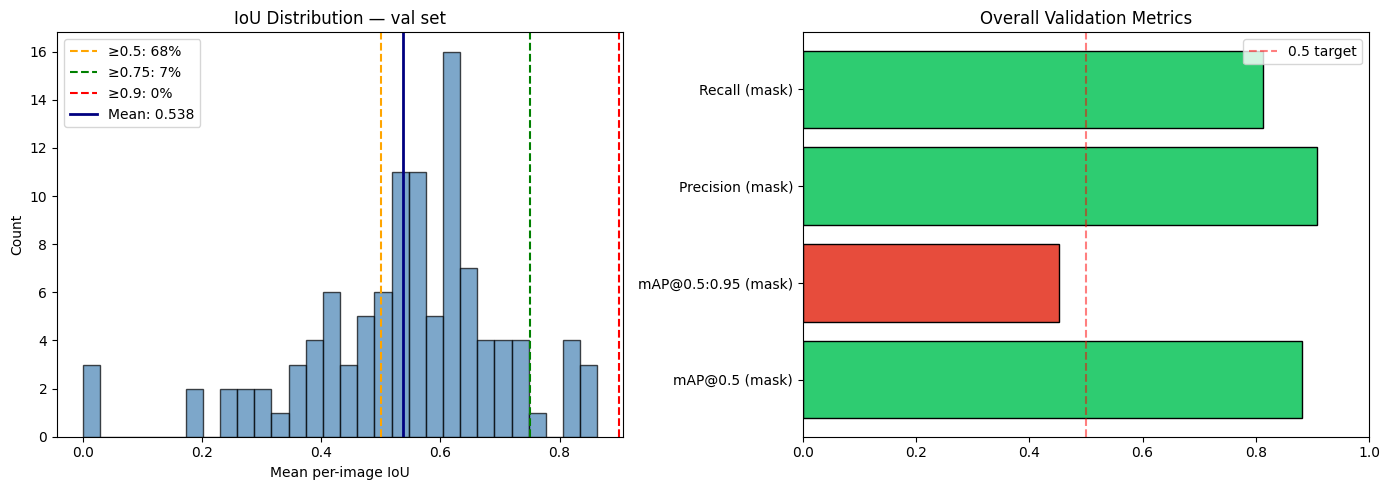

In [19]:
def iou_threshold_stats(df: pd.DataFrame, label: str = "val") -> None:
    """Print threshold stats and plot IoU distribution."""
    ious = df["mean_iou"].values
    for thr in (0.5, 0.75, 0.9):
        pct = (ious >= thr).mean() * 100
        print(f"  {label} | IoU >= {thr}: {pct:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(ious, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    for thr, col in [(0.5, "orange"), (0.75, "green"), (0.9, "red")]:
        axes[0].axvline(thr, color=col, linestyle="--", label=f"≥{thr}: {(ious >= thr).mean()*100:.0f}%")
    axes[0].axvline(ious.mean(), color="navy", linestyle="-", lw=2, label=f"Mean: {ious.mean():.3f}")
    axes[0].set_title(f"IoU Distribution — {label} set")
    axes[0].set_xlabel("Mean per-image IoU")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    keys = list(summary.keys())
    vals = list(summary.values())
    axes[1].barh(
        keys, vals,
        color=["#2ecc71" if v >= 0.5 else "#e74c3c" for v in vals],
        edgecolor="black",
    )
    axes[1].axvline(0.5, color="red", linestyle="--", alpha=0.5, label="0.5 target")
    axes[1].set_xlim(0, 1)
    axes[1].set_title("Overall Validation Metrics")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print("\nIoU threshold statistics:")
iou_threshold_stats(df_val, "val")



/tmp/ipykernel_4111/2018832620.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


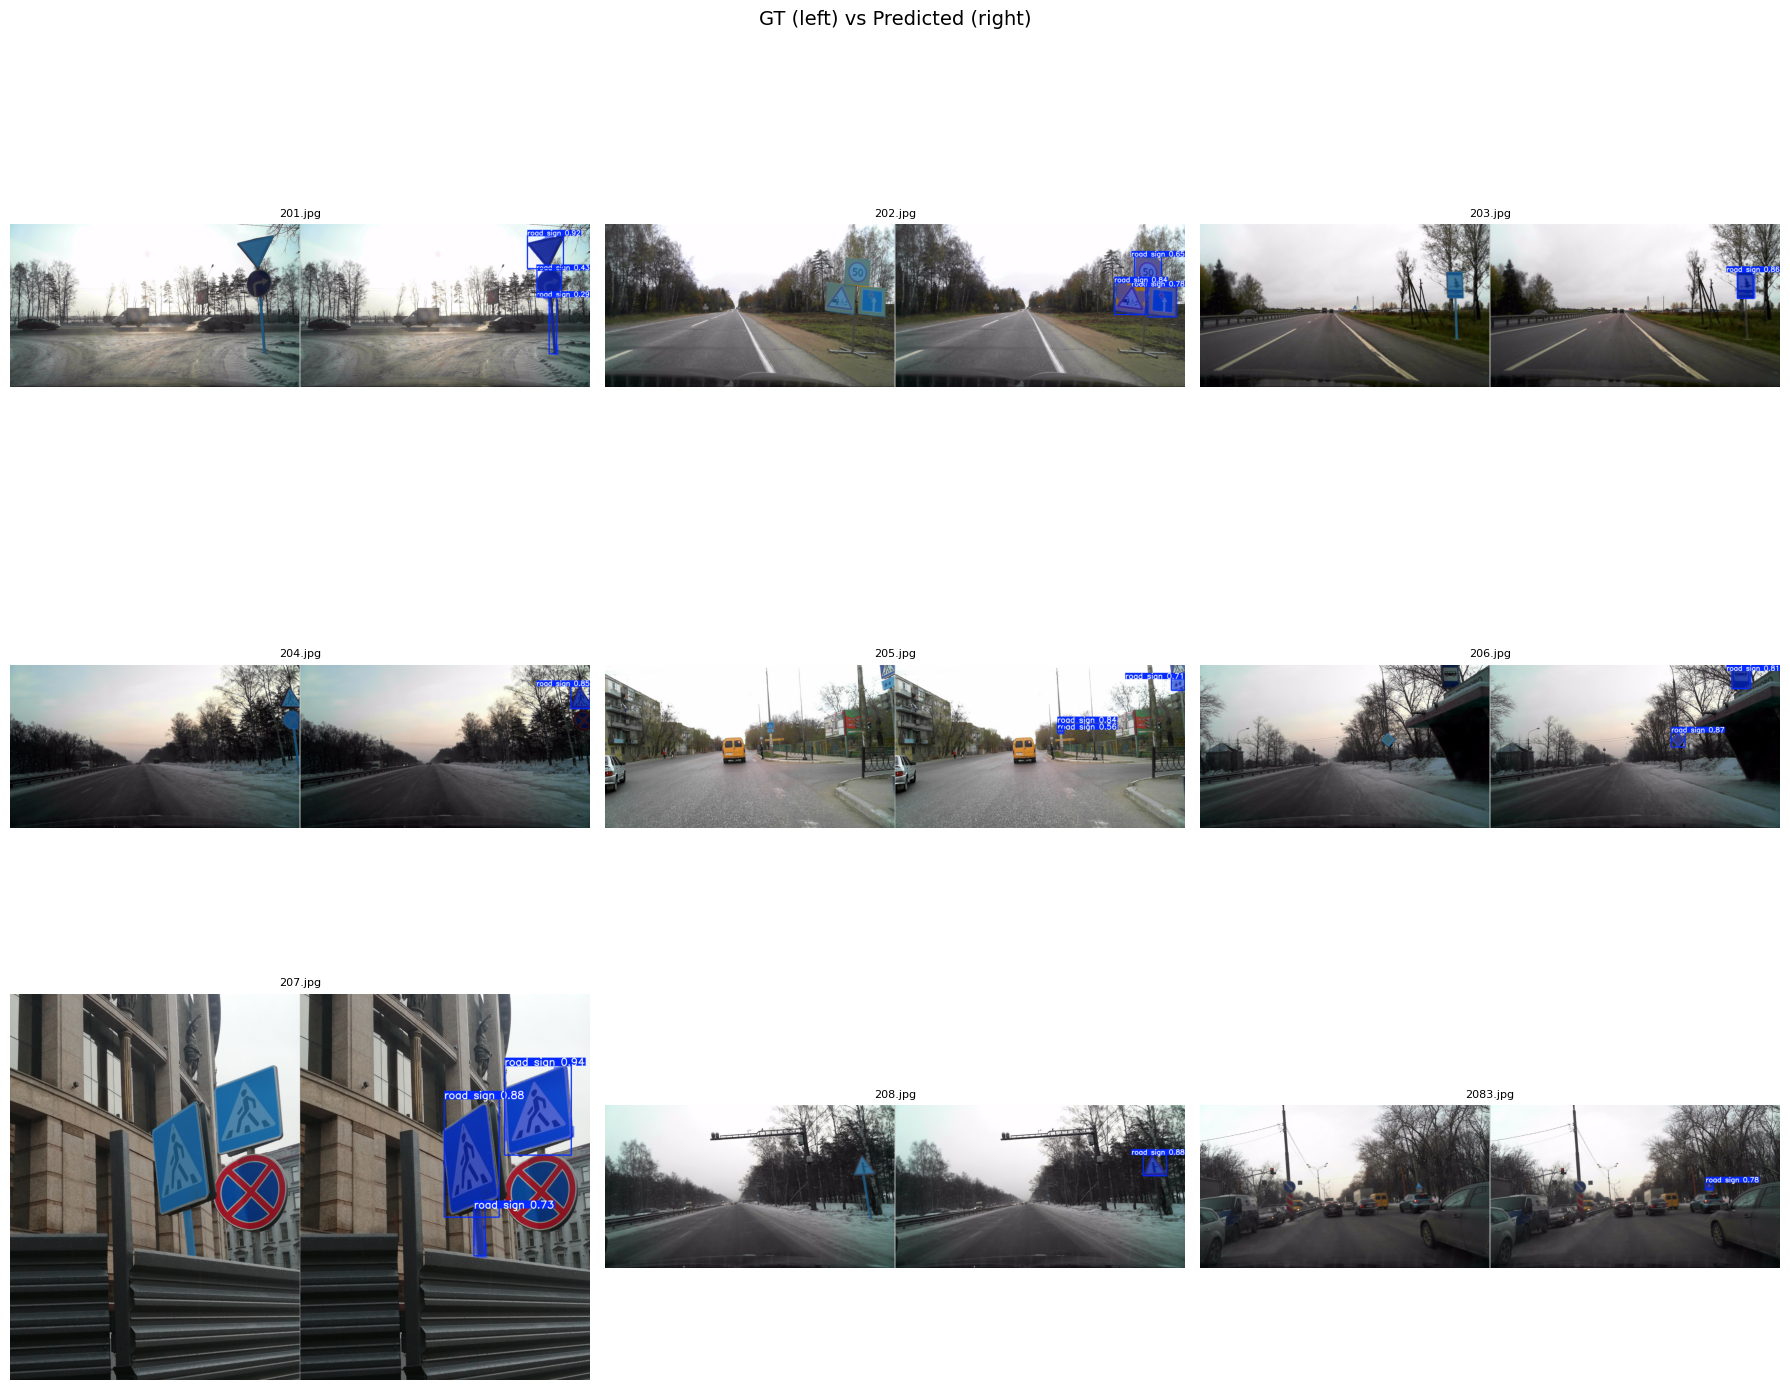

In [20]:
def visualize_predictions(model: YOLO, dataset_path: Path, split: str = "valid", n: int = 9) -> None:
    """Show GT mask overlay vs predicted mask overlay side by side."""
    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"
    image_files = sorted(images_dir.glob("*"))[:n]

    cols = 3
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    ax_flat = axes.flat

    cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

    for ax, img_path in zip(ax_flat, image_files):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]

        result = model.predict(
            source=str(img_path), conf=cfg.conf_threshold, device=cfg.device, verbose=False
        )[0]
        annotated = result.plot()[..., ::-1]  # BGR → RGB

        # GT overlay (green tint)
        gt_overlay = img.copy()
        label_path = labels_dir / (img_path.stem + ".txt")
        if label_path.exists():
            for line in label_path.read_text().strip().splitlines():
                parts = list(map(float, line.split()))
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                coords = np.array(parts[1:]).reshape(-1, 2)
                mask = _polygon_to_mask(coords, h_img, w_img)
                color = (np.array(cmap(cls_id)[:3]) * 255).astype(np.uint8)
                gt_overlay[mask == 1] = (gt_overlay[mask == 1] * 0.4 + color * 0.6).astype(np.uint8)

        # Stack GT | Pred side by side
        divider = np.ones((h_img, 4, 3), dtype=np.uint8) * 200
        combined = np.concatenate([gt_overlay, divider, annotated], axis=1)
        ax.imshow(combined)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    for ax in ax_flat[len(image_files):]:
        ax.axis("off")

    plt.suptitle("GT (left) vs Predicted (right)", fontsize=14)
    plt.tight_layout()
    plt.show()


visualize_predictions(model, roadsigns_path, "val", n=9)


## 4. Детекция на личных видео

Found 4 video(s)


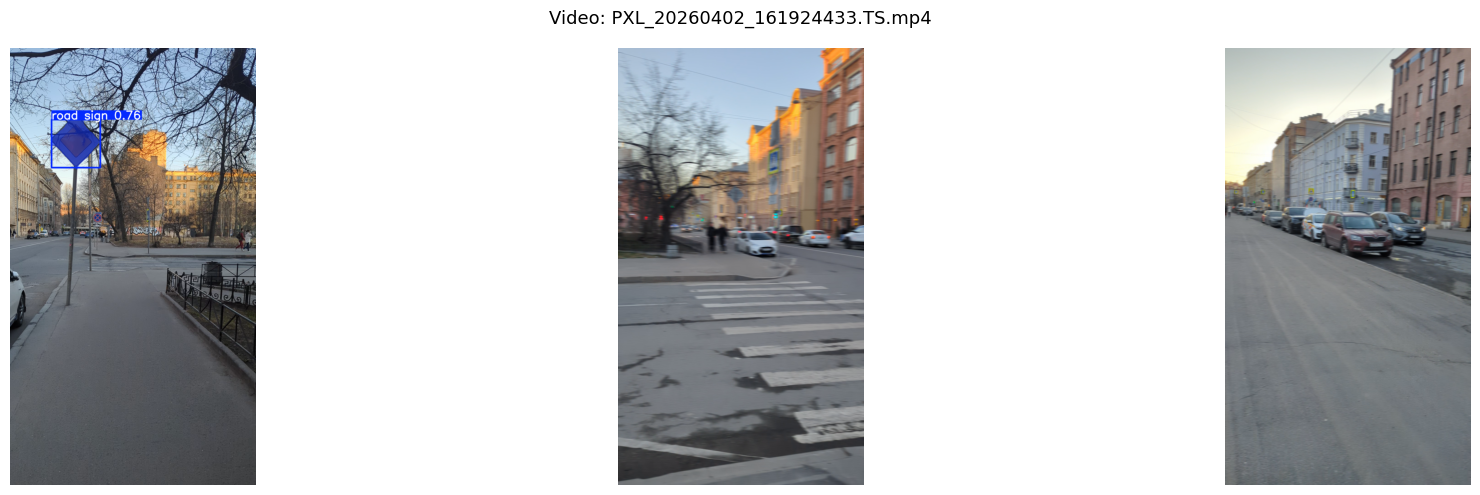

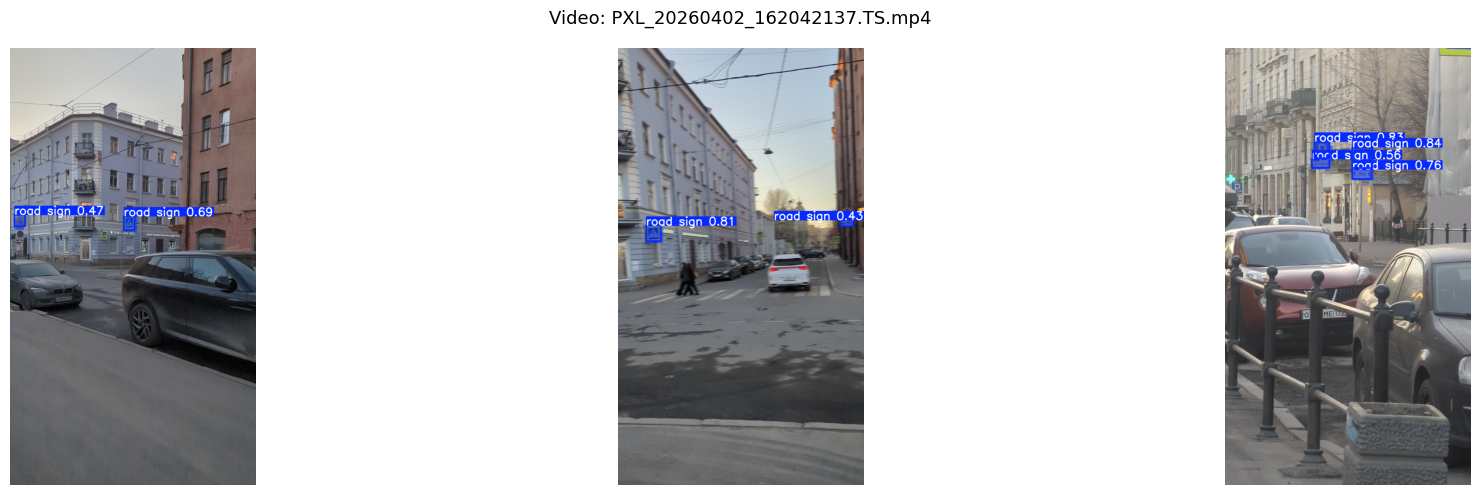

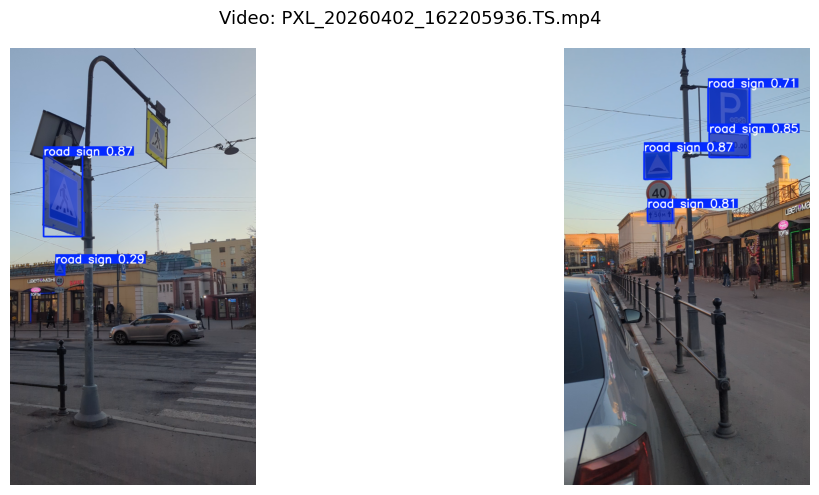

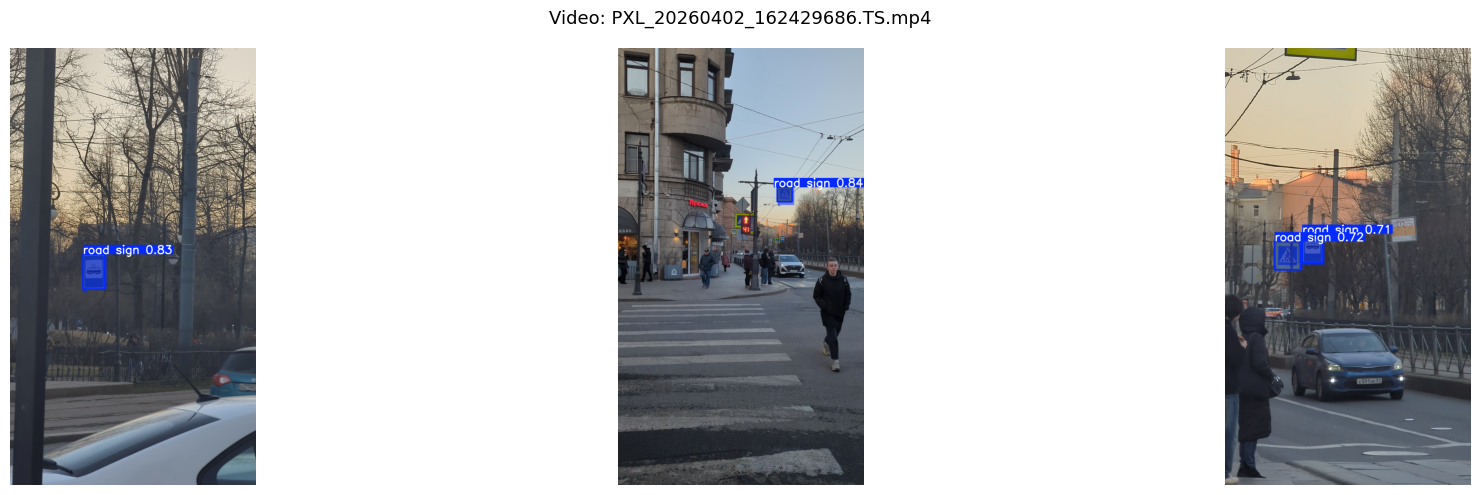

In [26]:
def collect_videos(videos_dir: Path) -> list[Path]:
    videos_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for ext in ("*.mp4", "*.avi", "*.mov", "*.MOV"):
        paths.extend(sorted(videos_dir.glob(ext)))
    if not paths:
        print(f"No videos found in {videos_dir}/")
        print("Add ≥3 videos (30+ sec each) and re-run.")
    else:
        print(f"Found {len(paths)} video(s)")
    return paths


def show_video_frames(model: YOLO, video_paths: list[Path], n_frames: int = 3) -> None:
    """Sample n_frames evenly-spaced frames per video, run inference, display grid.

    Does NOT process every frame — avoids redundant full-video pass before tracking.
    """
    for vp in video_paths:
        cap = cv2.VideoCapture(str(vp))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, total - 1, n_frames, dtype=int)

        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ret, frame = cap.read()
            if not ret:
                continue
            result = model.predict(
                source=frame, conf=cfg.conf_threshold, max_det=100,
                device=cfg.device, verbose=False,
            )[0]
            frames.append(result.plot()[..., ::-1])
        cap.release()

        if not frames:
            continue

        _, axes = plt.subplots(1, len(frames), figsize=(7 * len(frames), 5))
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        for ax, frm in zip(axes, frames):
            ax.imshow(frm)
            ax.axis("off")
        plt.suptitle(f"Video: {vp.name}", fontsize=13)
        plt.tight_layout()
        plt.show()


video_paths = collect_videos(cfg.videos_dir)
show_video_frames(model, video_paths)

## 5. Трекинг: ByteTrack и BoTSORT



Запускаем оба встроенных в ultralytics трекера на каждом видео.

Считаем метрику **ID Switches** — сколько раз один и тот же объект

(IoU > 0.5 между кадрами) получил новый ID.

In [27]:
def run_tracking(model: YOLO, video_path: Path, tracker: str) -> pd.DataFrame:
    """Run object tracking on a single video; return per-detection DataFrame.

    Columns: frame_id, track_id, cls, x1, y1, x2, y2
    """
    records = []
    frame_id = 0

    for result in model.track(
        source=str(video_path),
        conf=cfg.conf_threshold,
        device=cfg.device,
        tracker=tracker,
        stream=True,
        verbose=False,
    ):
        if result.boxes is None or result.boxes.id is None:
            frame_id += 1
            continue
        boxes = result.boxes.xyxy.cpu().numpy()
        ids = result.boxes.id.cpu().numpy().astype(int)
        clss = result.boxes.cls.cpu().numpy().astype(int)
        for box, tid, cls in zip(boxes, ids, clss):
            records.append({
                "frame_id": frame_id,
                "track_id": int(tid),
                "cls": int(cls),
                "x1": float(box[0]), "y1": float(box[1]),
                "x2": float(box[2]), "y2": float(box[3]),
            })
        frame_id += 1

    return pd.DataFrame(records)


def _box_iou(a: np.ndarray, b: np.ndarray) -> float:
    """IoU between two boxes [x1, y1, x2, y2]."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def compute_id_switches(df: pd.DataFrame, iou_threshold: float = 0.5) -> int:
    """Count ID switches: same spatial object (IoU > threshold) in consecutive frames gets new ID.

    Algorithm:
      For each consecutive pair of frames, build a cost matrix (IoU between all pairs).
      Greedily match detections. A switch is counted when matched pair has different track_id
      AND both IDs appeared in the previous-frame set (i.e. an existing track changed ID).
    """
    if df.empty:
        return 0

    switches = 0
    frames = sorted(df["frame_id"].unique())

    for i in range(len(frames) - 1):
        prev = df[df["frame_id"] == frames[i]]
        curr = df[df["frame_id"] == frames[i + 1]]
        if prev.empty or curr.empty:
            continue

        for _, cur_row in curr.iterrows():
            cur_box = np.array([cur_row["x1"], cur_row["y1"], cur_row["x2"], cur_row["y2"]])
            best_iou, best_prev_id = 0.0, -1
            for _, prev_row in prev.iterrows():
                prev_box = np.array([prev_row["x1"], prev_row["y1"], prev_row["x2"], prev_row["y2"]])
                iou = _box_iou(cur_box, prev_box)
                if iou > best_iou:
                    best_iou = iou
                    best_prev_id = int(prev_row["track_id"])
            if best_iou >= iou_threshold and best_prev_id != int(cur_row["track_id"]):
                # Same spatial object, new ID → ID switch
                switches += 1

    return switches



In [28]:
TRACKERS = {"ByteTrack": "bytetrack.yaml", "BoTSORT": "botsort.yaml"}

tracking_results: dict[str, dict[str, pd.DataFrame]] = {}  # tracker → video → df
id_switches: dict[str, dict[str, int]] = {}

for tracker_name, tracker_cfg in TRACKERS.items():
    tracking_results[tracker_name] = {}
    id_switches[tracker_name] = {}

    for vp in video_paths:
        print(f"\nTracking [{tracker_name}] on {vp.name} ...")
        df_track = run_tracking(model, vp, tracker_cfg)
        tracking_results[tracker_name][vp.name] = df_track
        ids_count = compute_id_switches(df_track)
        id_switches[tracker_name][vp.name] = ids_count
        print(f"  Detections: {len(df_track)} | ID Switches: {ids_count}")



Tracking [ByteTrack] on PXL_20260402_161924433.TS.mp4 ...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 355ms
Prepared 1 package in 69ms
Installed 1 package in 12ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  Detections: 1741 | ID Switches: 3

Tracking [ByteTrack] on PXL_20260402_162042137.TS.mp4 ...
  Detections: 1823 | ID Switches: 1

Tracking [ByteTrack] on PXL_20260402_162205936.TS.mp4 ...
  Detections: 1356 | ID Switches: 0

Tracking [ByteTrack] on PXL_20260402_162429686.TS.mp4 ...
  Detections: 1957 | ID Switches: 1

Tracking [BoTSORT] on PXL_20260402_161924433.TS.mp4 ...
  Detections: 1929 | ID Switches: 3

Tracking [BoTSORT] on PXL_20260402_162042137.TS.mp4 ...
  Detections: 2452 | ID Switches: 2

Tracking [BoTSORT] on PXL_20260402_162205936.TS.mp4 ...
  Detections: 1590 


ID Switches Summary:
           PXL_20260402_161924433.TS.mp4  PXL_20260402_162042137.TS.mp4  PXL_20260402_162205936.TS.mp4  PXL_20260402_162429686.TS.mp4
Tracker                                                                                                                              
ByteTrack                              3                              1                              0                              1
BoTSORT                                3                              2                              1                              0


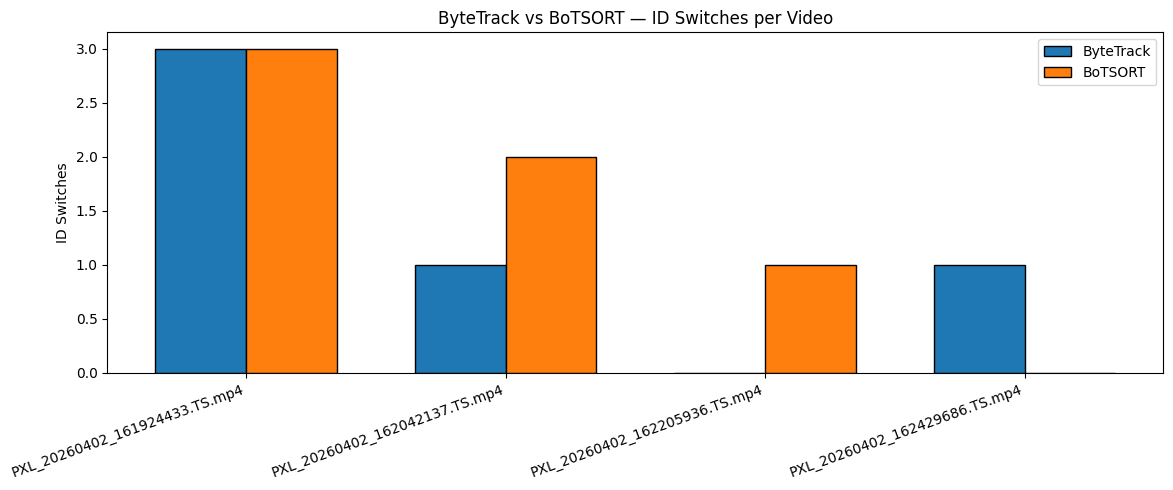

In [29]:
if video_paths:
    ids_df = pd.DataFrame(id_switches).T  # rows=trackers, cols=videos
    ids_df.index.name = "Tracker"
    print("\nID Switches Summary:")
    print(ids_df.to_string())

    fig, ax = plt.subplots(figsize=(max(8, len(video_paths) * 3), 5))
    x = np.arange(len(video_paths))
    width = 0.35
    for i, (tname, _) in enumerate(TRACKERS.items()):
        vals = [id_switches[tname].get(vp.name, 0) for vp in video_paths]
        ax.bar(x + i * width, vals, width, label=tname, edgecolor="black")

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([vp.name for vp in video_paths], rotation=20, ha="right")
    ax.set_ylabel("ID Switches")
    ax.set_title("ByteTrack vs BoTSORT — ID Switches per Video")
    ax.legend()
    plt.tight_layout()
    plt.show()



/tmp/ipykernel_4111/2485407426.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


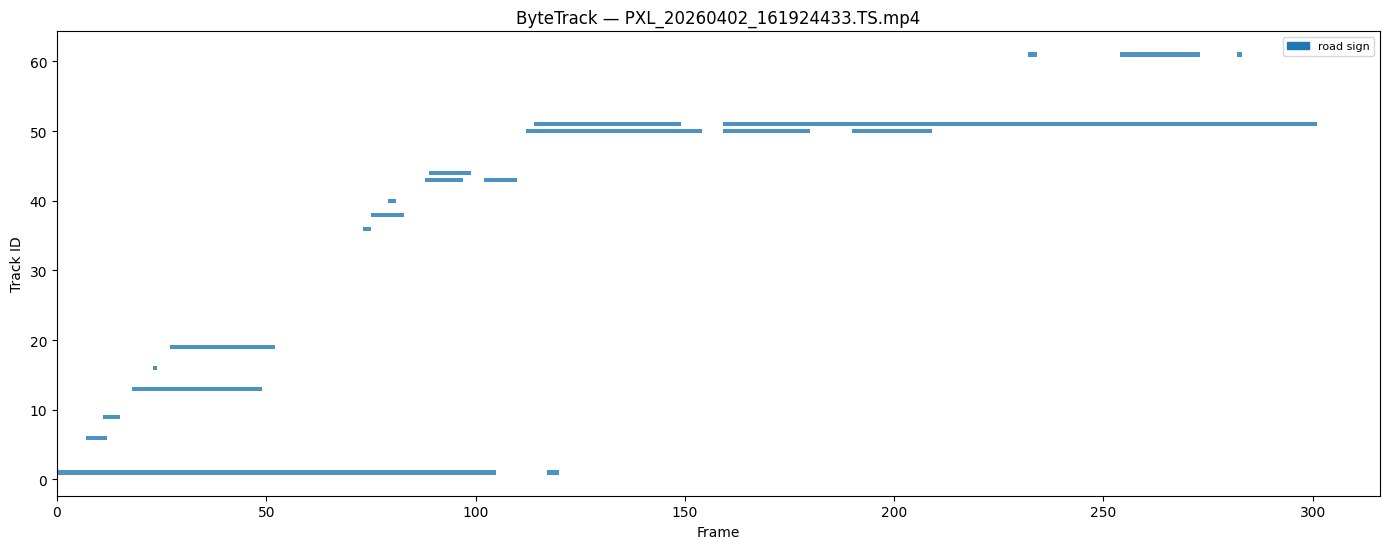

/tmp/ipykernel_4111/2485407426.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


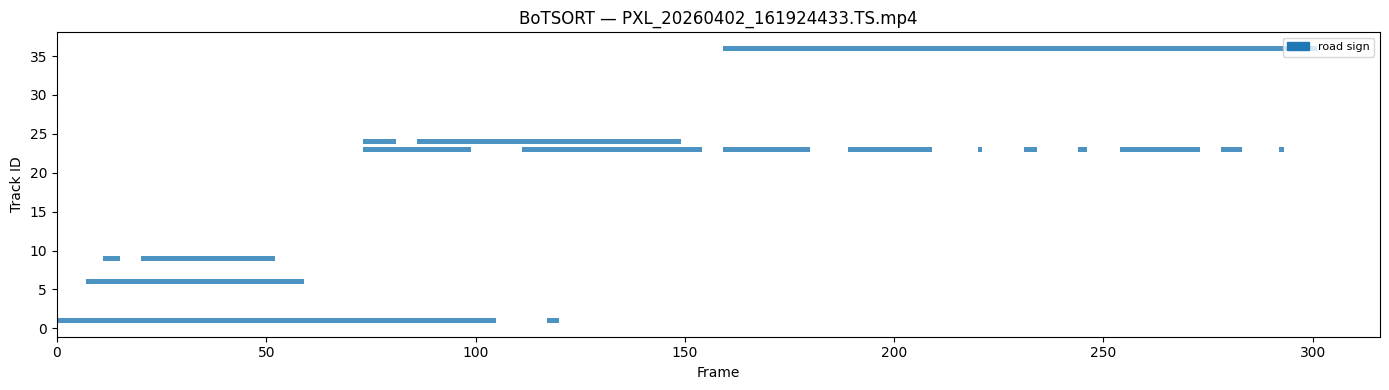

In [30]:
def plot_track_timeline(df: pd.DataFrame, title: str = "", max_frames: int = 300) -> None:
    """Plot track ID lifetimes: x=frame, horizontal bars per track_id colored by class."""
    if df.empty:
        print("No tracking data to plot.")
        return

    df = df[df["frame_id"] <= df["frame_id"].min() + max_frames].copy()
    track_ids = df["track_id"].unique()
    cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

    fig, ax = plt.subplots(figsize=(14, max(4, len(track_ids) * 0.4)))
    for tid in sorted(track_ids):
        sub = df[df["track_id"] == tid]
        cls = int(sub["cls"].mode()[0])
        color = cmap(cls % NUM_CLASSES)
        frames = sorted(sub["frame_id"].unique())
        # Draw segments (handle gaps)
        seg_start = frames[0]
        for j in range(1, len(frames)):
            if frames[j] - frames[j - 1] > 5:
                ax.barh(tid, frames[j - 1] - seg_start + 1, left=seg_start, height=0.6,
                        color=color, edgecolor="none", alpha=0.8)
                seg_start = frames[j]
        ax.barh(tid, frames[-1] - seg_start + 1, left=seg_start, height=0.6,
                color=color, edgecolor="none", alpha=0.8,
                label=CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls))

    handles = [plt.Rectangle((0, 0), 1, 1, color=cmap(i)) for i in range(NUM_CLASSES)]
    ax.legend(handles, CLASS_NAMES, loc="upper right", fontsize=8)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Track ID")
    ax.set_title(title or "Track ID Timeline")
    plt.tight_layout()
    plt.show()


if video_paths:
    first_video = video_paths[0].name
    for tname in TRACKERS:
        df_t = tracking_results[tname].get(first_video, pd.DataFrame())
        plot_track_timeline(df_t, title=f"{tname} — {first_video}")


## 6. Метрики на личных видео



Сравниваем уверенность детекций (confidence) на видео vs валидационном наборе.

Строим распределение confidence и количества детекций по кадрам.

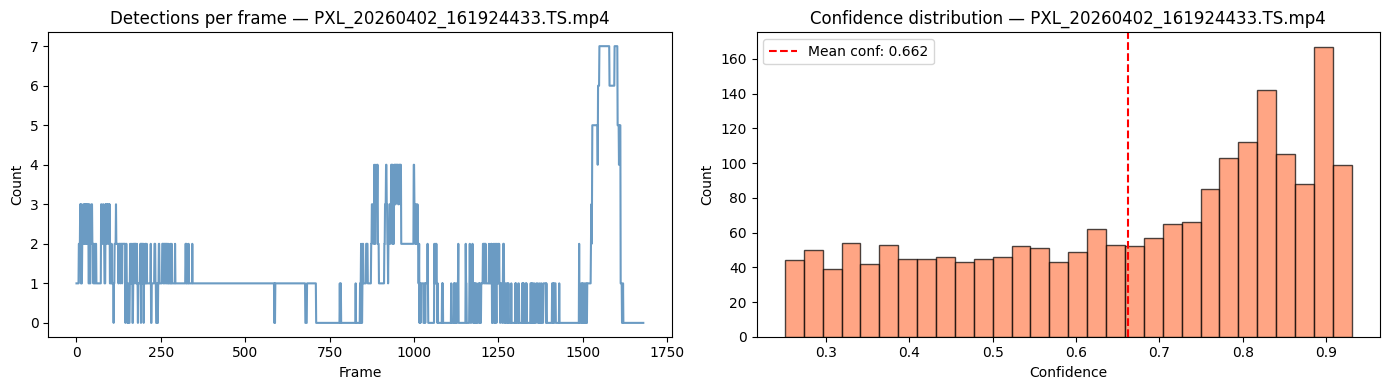

  PXL_20260402_161924433.TS.mp4: 1680 frames, mean dets/frame: 1.2, mean conf: 0.662


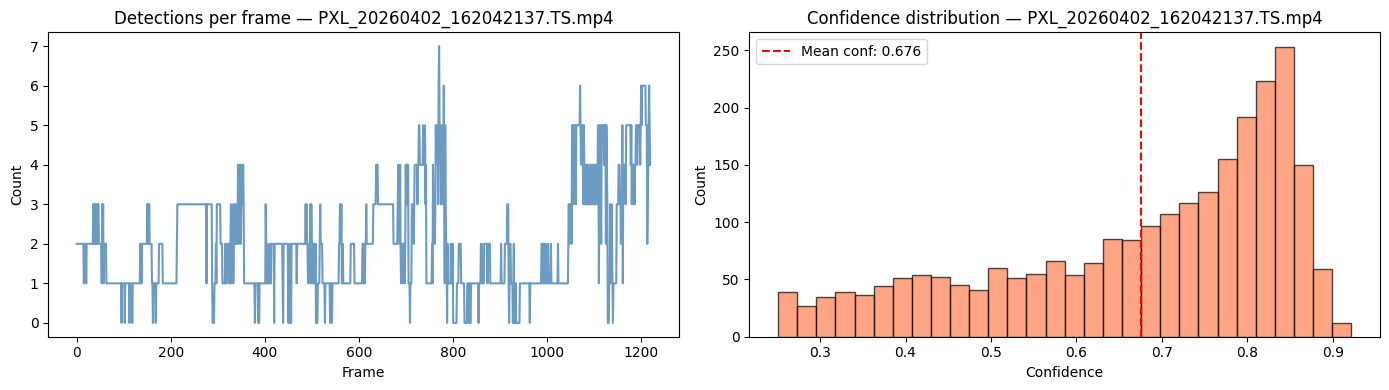

  PXL_20260402_162042137.TS.mp4: 1221 frames, mean dets/frame: 2.0, mean conf: 0.676


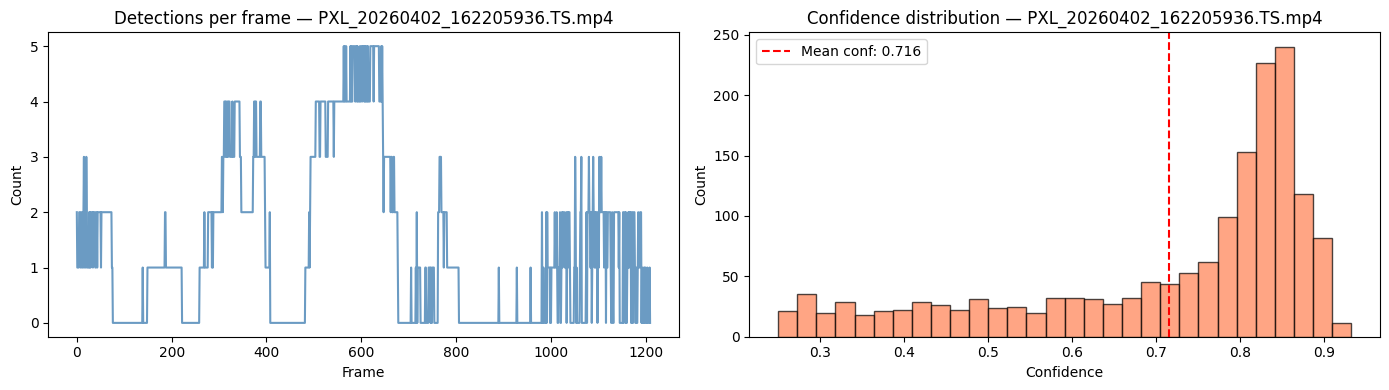

  PXL_20260402_162205936.TS.mp4: 1210 frames, mean dets/frame: 1.3, mean conf: 0.716


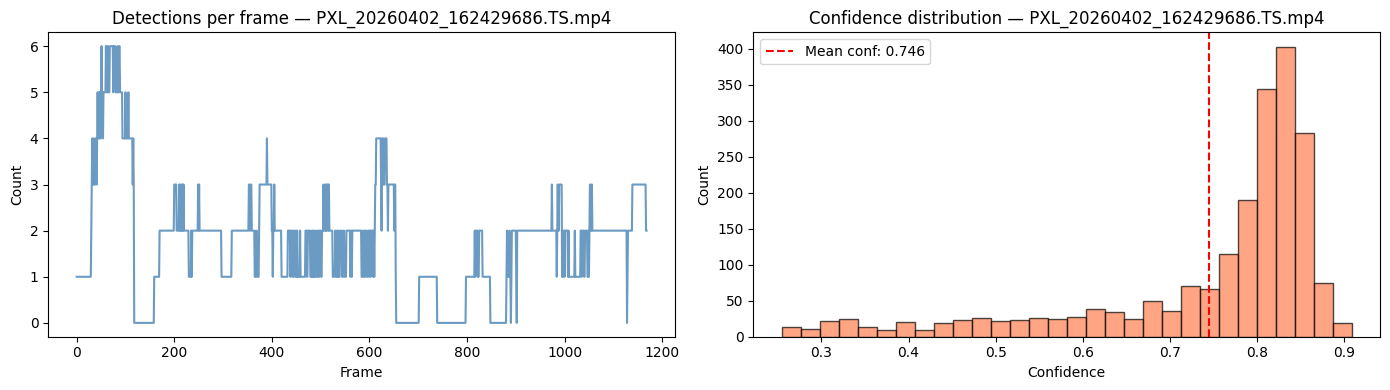

  PXL_20260402_162429686.TS.mp4: 1169 frames, mean dets/frame: 1.8, mean conf: 0.746


In [31]:
def video_detection_stats(model: YOLO, video_paths: list[Path]) -> None:
    """Plot per-frame detection count and confidence distribution for each video."""
    if not video_paths:
        return

    for vp in video_paths:
        frame_counts, all_confs = [], []
        for result in model.predict(
            source=str(vp), conf=cfg.conf_threshold, device=cfg.device,
            stream=True, verbose=False
        ):
            n = len(result.boxes) if result.boxes is not None else 0
            frame_counts.append(n)
            if result.boxes is not None and len(result.boxes) > 0:
                all_confs.extend(result.boxes.conf.cpu().tolist())

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(frame_counts, color="steelblue", alpha=0.8)
        axes[0].set_title(f"Detections per frame — {vp.name}")
        axes[0].set_xlabel("Frame")
        axes[0].set_ylabel("Count")

        if all_confs:
            axes[1].hist(all_confs, bins=30, edgecolor="black", alpha=0.7, color="coral")
            axes[1].axvline(np.mean(all_confs), color="red", linestyle="--",
                            label=f"Mean conf: {np.mean(all_confs):.3f}")
            axes[1].set_title(f"Confidence distribution — {vp.name}")
            axes[1].set_xlabel("Confidence")
            axes[1].set_ylabel("Count")
            axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"  {vp.name}: {len(frame_counts)} frames, "
              f"mean dets/frame: {np.mean(frame_counts):.1f}, "
              f"mean conf: {np.mean(all_confs):.3f}" if all_confs else
              f"  {vp.name}: no detections above conf threshold")


video_detection_stats(model, video_paths)
